# Solution 2D: Size and Value Sorts
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("merged.parquet")
df = df[df["close"] >= 5.0].dropna()
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")

Loaded: 533,156 rows, 6501 tickers


## 1. Size quintiles

In [2]:
df["size_quintile"] = df.groupby("month")["marketcap"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)
size_ret = df.groupby(["month", "size_quintile"])["return"].mean().reset_index()
size_avg = size_ret.groupby("size_quintile")["return"].mean()

print("Size quintile mean monthly returns:")
for q, r in size_avg.items():
    label = {1: "Smallest", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Largest"}.get(q, f"Q{int(q)}")
    print(f"  Q{int(q)} ({label:8s}): {r:.4f}  ({r*12:.2%} annualized)")

Size quintile mean monthly returns:
  Q1 (Smallest): -0.0020  (-2.35% annualized)
  Q2 (Q2      ): 0.0077  (9.23% annualized)
  Q3 (Q3      ): 0.0094  (11.32% annualized)
  Q4 (Q4      ): 0.0093  (11.11% annualized)
  Q5 (Largest ): 0.0104  (12.50% annualized)


Small stocks tend to have higher mean returns than large stocks, consistent with the well-documented **size effect**.

## 2. Book-to-market quintiles

In [3]:
df_bm = df[df["pb"] > 0].copy()
df_bm["bm"] = 1.0 / df_bm["pb"]
df_bm["bm_quintile"] = df_bm.groupby("month")["bm"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)
bm_ret = df_bm.groupby(["month", "bm_quintile"])["return"].mean().reset_index()
bm_avg = bm_ret.groupby("bm_quintile")["return"].mean()

print("B/M quintile mean monthly returns:")
for q, r in bm_avg.items():
    label = {1: "Growth", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Value"}.get(q, f"Q{int(q)}")
    print(f"  Q{int(q)} ({label:8s}): {r:.4f}  ({r*12:.2%} annualized)")

B/M quintile mean monthly returns:
  Q1 (Growth  ): 0.0075  (9.01% annualized)
  Q2 (Q2      ): 0.0079  (9.51% annualized)
  Q3 (Q3      ): 0.0072  (8.64% annualized)
  Q4 (Q4      ): 0.0065  (7.78% annualized)
  Q5 (Value   ): 0.0058  (6.96% annualized)


Value stocks (high B/M) tend to outperform growth stocks (low B/M), consistent with the **value premium**.

## 3. Double sort (size x B/M)

In [4]:
df_bm["size_tercile"] = df_bm.groupby("month")["marketcap"].transform(
    lambda x: pd.qcut(x, 3, labels=["Small", "Medium", "Large"], duplicates="drop")
)
df_bm["bm_tercile"] = df_bm.groupby("month")["bm"].transform(
    lambda x: pd.qcut(x, 3, labels=["Growth", "Neutral", "Value"], duplicates="drop")
)
double = df_bm.groupby(["month", "size_tercile", "bm_tercile"])["return"].mean().reset_index()
table = double.groupby(["size_tercile", "bm_tercile"])["return"].mean().reset_index()
table = table.pivot(index="size_tercile", columns="bm_tercile", values="return")
table = table.reindex(["Small", "Medium", "Large"])[["Growth", "Neutral", "Value"]]
print("Mean monthly return (rows=size, columns=B/M):")
print(table.round(4).to_string())

Mean monthly return (rows=size, columns=B/M):
bm_tercile    Growth  Neutral   Value
size_tercile                         
Small        -0.0041   0.0016  0.0039
Medium        0.0101   0.0086  0.0088
Large         0.0109   0.0087  0.0105


C:\Users\kerry\AppData\Local\Temp\ipykernel_71740\2715487501.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  double = df_bm.groupby(["month", "size_tercile", "bm_tercile"])["return"].mean().reset_index()
C:\Users\kerry\AppData\Local\Temp\ipykernel_71740\2715487501.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = double.groupby(["size_tercile", "bm_tercile"])["return"].mean().reset_index()


## 4. Size quintile bar chart

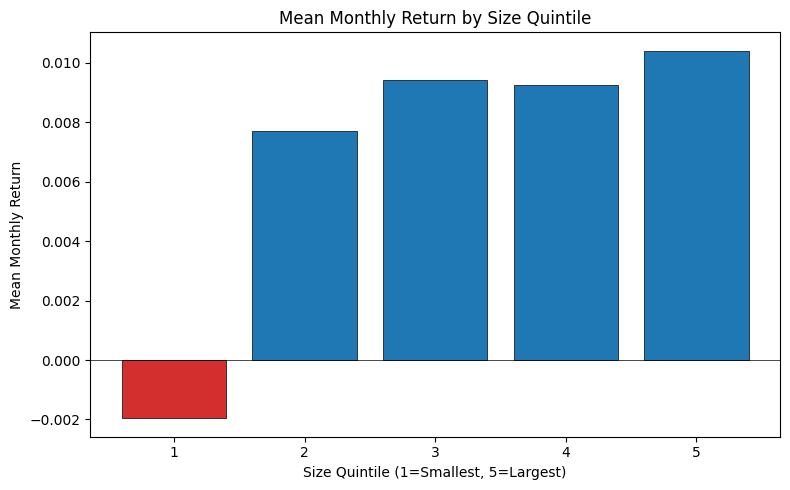

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1f77b4" if r >= 0 else "#d32f2f" for r in size_avg.values]
ax.bar(size_avg.index.astype(int), size_avg.values, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Size Quintile (1=Smallest, 5=Largest)")
ax.set_ylabel("Mean Monthly Return")
ax.set_title("Mean Monthly Return by Size Quintile")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.show()

## 5. Discussion

The value premium (high B/M minus low B/M) appears stronger among small stocks than among large stocks. This is consistent with the Fama-French finding that value and size effects interact, with the value effect concentrated among smaller firms where mispricing is more likely to persist.